# 7.1

In [49]:
from numpy import linalg as la
import numpy as np

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(la.det(A))

B = np.array([1,2,3,2,0,-4,1,2,0,3,-1,-1]).reshape(3,4)
x,y,z = la.solve(B[:,:3],B[:,3])
print("x =", x, "y =", y, "z =", z)


AT = np.transpose(A)
if np.allclose(la.inv(A), AT):
    print("A is orthogonal")
else:
    print("A is not orthogonal")

print("eigenvalues:", la.eigvals(A))

1.0
x = 10.0 y = -1.0 z = -2.0
A is not orthogonal
eigenvalues: [ 1.         -4.79128785 -0.20871215]


# 7.3

In [50]:
import numpy as np
from numpy import linalg as la
alpha = 180-123
beta = 90-27.4
gamma = 192.25
Ex = np.array([1,0,0,0,np.cos(np.radians(alpha)),np.sin(np.radians(alpha)),0,-np.sin(np.radians(alpha)),np.cos(np.radians(alpha))]).reshape(3,3)
Ey = np.array([np.cos(np.radians(beta)),0,-np.sin(np.radians(beta)),0,1,0,np.sin(np.radians(beta)),0,np.cos(np.radians(beta))]).reshape(3,3)
Ezgamma = np.array([np.cos(np.radians(gamma)),np.sin(np.radians(gamma)),0,-np.sin(np.radians(gamma)),np.cos(np.radians(gamma)),0,0,0,1]).reshape(3,3)
Ezalpha = np.array([np.cos(np.radians(alpha)),np.sin(np.radians(alpha)),0,-np.sin(np.radians(alpha)),np.cos(np.radians(alpha)),0,0,0,1]).reshape(3,3)
E = Ezalpha @ Ey @ Ezgamma

print(E)

det_E = la.det(E)
ET = E.T
E_orthogonal_check = ET @ E
E_inv = la.inv(E)

if np.isclose(det_E, 1) and np.allclose(E_orthogonal_check, np.eye(3)):
    print("E is a rotation matrix")
else:
    print("E is NOT a rotation matrix")

if np.any(np.isclose(la.eigvals(E), 1)):
    print("E has an eigenvalue of 1")
else:
    print("E does NOT have an eigenvalue of 1")

al = np.radians(192.25)
gam = np.radians(27.4)
Rz = np.array([np.cos(al)*np.cos(gam), np.cos(gam)*np.sin(al), np.sin(gam)]).reshape(3,1)
print("Rz:", Rz,"with norm:", la.norm(Rz))

V2 = np.round(E @ Rz)
print("V2:", V2)


[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
E is a rotation matrix
E has an eigenvalue of 1
Rz: [[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]] with norm: 1.0
V2: [[0.]
 [0.]
 [1.]]


# 7.5

Coefficients: [ 2.18582332e+02 -5.51003145e+02  5.65812236e+02 -3.13633555e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059755e-01
  1.09925609e-02 -2.17117476e-04]
A: (10, 10)


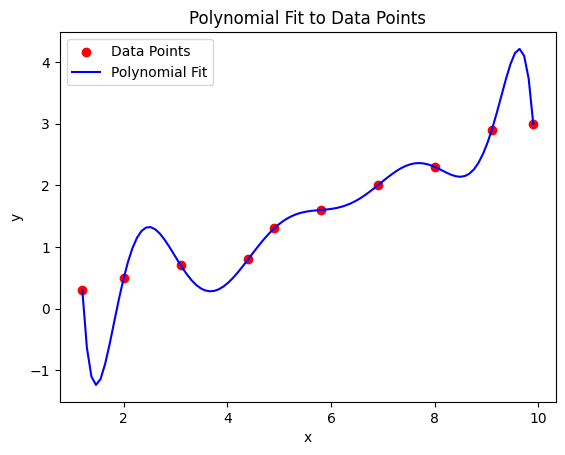

In [26]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

A = np.zeros((len(x),len(x)))
for i in range(len(x)):
    for j in range(len(x)):
        A[i,j] = x[i]**j
coefficients = la.solve(A, y)
print("Coefficients:", coefficients)

print("A:",np.shape(A))

x_poly = np.linspace(min(x), max(x), 100)
y_poly = np.zeros_like(x_poly)
for i in range(len(x)):
    y_poly += coefficients[i] * x_poly**i

fig,ax = plt.subplots()
ax.scatter(x, y, color='red', label='Data Points')
ax.plot(x_poly, y_poly, color='blue', label='Polynomial Fit')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Polynomial Fit to Data Points')
ax.legend()
plt.show()

# 7.6

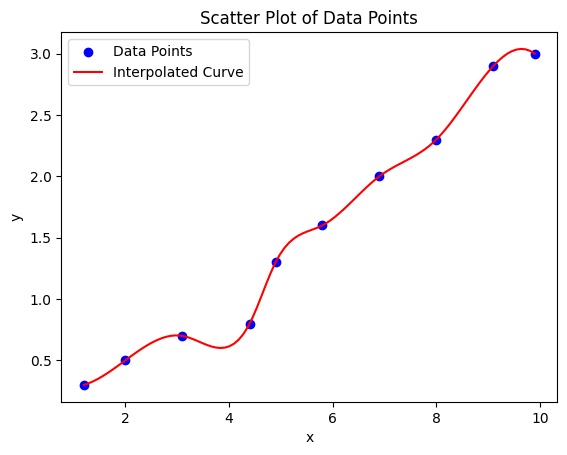

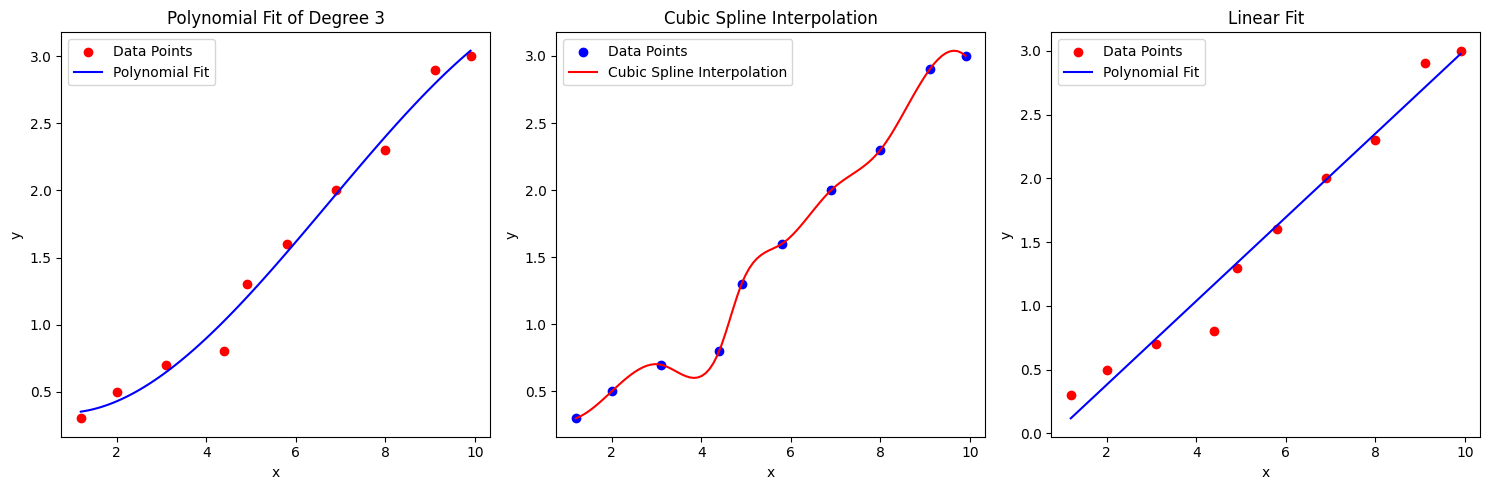

Interpolation at x = [3.5, 5.5, 7.5]
Linear: [0.73076923 1.5        2.16363636]
Polynomial (degree 3): [0.74895593 1.42318688 2.20941539]
Cubic: [0.63867383 1.54912493 2.14734116]


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

inter = ip.interp1d(x, y, kind='cubic')
x_new = np.linspace(min(x), max(x), 100)
y_new = inter(x_new)

fig, ax = plt.subplots()
ax.scatter(x, y, color='blue', label='Data Points')
ax.plot(x_new, y_new, color='red', label='Interpolated Curve')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Scatter Plot of Data Points')
ax.legend()
plt.show()

#Shorter and easier way to do polynomial fit using numpy's polyfit

class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def polynomial_fit(self, degree):
        coefficients = np.polyfit(self.x, self.y, degree)
        return coefficients

    def plot_polynomial_fit(self, degree, ax=None):
        coefficients = self.polynomial_fit(degree)
        x_poly = np.linspace(min(self.x), max(self.x), 100)
        y_poly = np.polyval(coefficients, x_poly)

        if ax is None:
            fig, ax = plt.subplots()
        ax.scatter(self.x, self.y, color='red', label='Data Points')
        ax.plot(x_poly, y_poly, color='blue', label='Polynomial Fit')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if degree == 1:
            ax.set_title('Linear Fit')
        else:
            ax.set_title(f'Polynomial Fit of Degree {degree}')
        ax.legend()
        if ax is None:
            plt.show()
    
    def cubic_spline_interpolation(self, ax=None):
        inter = ip.interp1d(self.x, self.y, kind='cubic')
        x_new = np.linspace(min(self.x), max(self.x), 100)
        y_new = inter(x_new)

        if ax is None:
            fig, ax = plt.subplots()
        ax.scatter(self.x, self.y, color='blue', label='Data Points')
        ax.plot(x_new, y_new, color='red', label='Cubic Spline Interpolation')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Cubic Spline Interpolation')
        ax.legend()
        if ax is None:
            plt.show()
    
    def plot_linear_fit(self, ax=None):
        self.plot_polynomial_fit(1, ax=ax)
    
    def interpolate_at(self, new_x, method='linear', degree=3):
        if method == 'linear':
            interp = ip.interp1d(self.x, self.y, kind='linear', bounds_error=False, fill_value='extrapolate')
            return interp(new_x)
        elif method == 'cubic':
            interp = ip.interp1d(self.x, self.y, kind='cubic', bounds_error=False, fill_value='extrapolate')
            return interp(new_x)
        elif method == 'poly':
            coeffs = np.polyfit(self.x, self.y, degree)
            return np.polyval(coeffs, new_x)

# Examples:
ipi = interpolation(x, y)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ipi.plot_polynomial_fit(degree=3, ax=axes[0])
ipi.cubic_spline_interpolation(ax=axes[1])
ipi.plot_linear_fit(ax=axes[2])
plt.tight_layout()
plt.show()

#Interpolate at:
new_x_values = [3.5, 5.5, 7.5]
print("Interpolation at x =", new_x_values)
print("Linear:", ipi.interpolate_at(new_x_values, method='linear'))
print("Polynomial (degree 3):", ipi.interpolate_at(new_x_values, method='poly', degree=3))
print("Cubic:", ipi.interpolate_at(new_x_values, method='cubic'))

# 7.7

In [28]:
import numpy as np
I = np.array([[2.0, 4.1], 
              [2.5, 3.8]])
pos_x, pos_y = 0.2, 0.7
def bilinear_interpolation(grid, x, y):
    I0, I1 = grid[0, 0], grid[0, 1]
    I2, I3 = grid[1, 0], grid[1, 1]
    
    lam = x 
    mu = y

    ipi = (
        (1 - lam) * (1 - mu) * I0 +
        (lam) * (1 - mu) * I1 +
        (mu) * (1 - lam) * I2 +
        (lam) * (mu) * I3
    )
    
    return ipi


result = bilinear_interpolation(I, pos_x, pos_y)

print(f"The interpolated intensity at x={pos_x}, y={pos_y} is: {result:.3f}")

The interpolated intensity at x=0.2, y=0.7 is: 2.658


# 7.10

Using leastsq: Optimal Hubble constant H = 66.03 km/s/Mpc
Reduced chi-squared = 49.82
Uncertainty in H (leastsq) = 5.82 km/s/Mpc
Using curve_fit: Optimal Hubble constant H = 66.03 km/s/Mpc
Uncertainty in H (curve_fit) = 5.82 km/s/Mpc


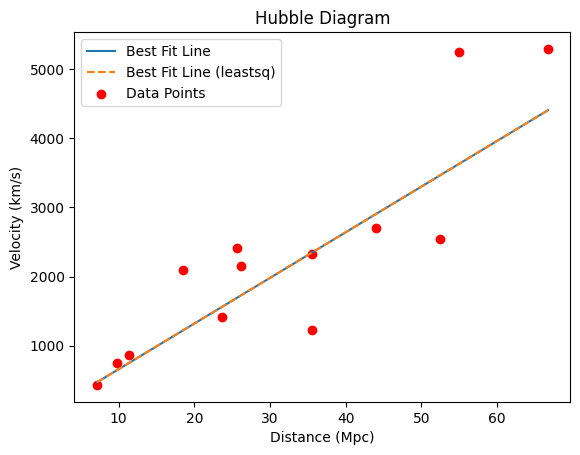

In [32]:
from scipy import optimize as opt
import numpy as np
import matplotlib.pyplot as plt

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
d = data[0::4]
ed = data[2::4]
v = data[1::4]
ev = data[3::4]


def residual(params):
    H = params[0]
    model_v = H * np.array(d)
    return (np.array(v) - model_v) / np.array(ev)

initial_guess = [50.0]

result = opt.leastsq(residual, initial_guess)

H_opt_leastsq = result[0][0]

print(f"Using leastsq: Optimal Hubble constant H = {H_opt_leastsq:.2f} km/s/Mpc")

residuals = residual([H_opt_leastsq])
chi_squared = np.sum(residuals**2)
dof = len(d) - 1  
reduced_chi_squared = chi_squared / dof

print(f"Reduced chi-squared = {reduced_chi_squared:.2f}")

sum_weighted_d_squared = np.sum( (np.array(d) / np.array(ev))**2 )
sigma_H_leastsq = np.sqrt( reduced_chi_squared / sum_weighted_d_squared )

print(f"Uncertainty in H (leastsq) = {sigma_H_leastsq:.2f} km/s/Mpc")

def model(d, H):
    return H * d

popt, pcov = opt.curve_fit(model, d, v, sigma=ev, p0=[50.0])

H_opt_curvefit = popt[0]
sigma_H_curvefit = np.sqrt(pcov[0,0])

print(f"Using curve_fit: Optimal Hubble constant H = {H_opt_curvefit:.2f} km/s/Mpc")
print(f"Uncertainty in H (curve_fit) = {sigma_H_curvefit:.2f} km/s/Mpc")

fig, ax = plt.subplots()
d_fit_curve = np.linspace(min(d), max(d), 100)
v_fit_curve = model(d_fit_curve, H_opt_curvefit)
ax.plot(d_fit_curve, v_fit_curve, label='Best Fit Line')
d_fit_leastsq = np.linspace(min(d), max(d), 100)
v_fit_leastsq = model(d_fit_leastsq, H_opt_leastsq)
ax.plot(d_fit_leastsq, v_fit_leastsq, label='Best Fit Line (leastsq)', linestyle='--')
ax.scatter(d, v, color='red', label='Data Points')
ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Velocity (km/s)')
ax.set_title('Hubble Diagram')
ax.legend()
plt.show()